In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEMOVO.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [8]:
df = data
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [9]:
data.iloc[:,-3] == 1

0       True
1       True
2       True
3       True
4       True
       ...  
583    False
584    False
585    False
586    False
587    False
Name: gender, Length: 588, dtype: bool

In [10]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [11]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,17.334037,17.539159,17.562779,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,16.263369,17.699334,19.162629,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,18.860587,18.714656,19.843059,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,15.868680,18.698590,19.053175,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,16.198743,17.339091,18.793145,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,16.535757,15.881800,18.443654,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,16.113687,16.514813,18.799787,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,14.285399,16.010688,18.472471,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,14.503504,15.854289,17.343597,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469


In [12]:
y

0      1
1      1
2      1
3      1
4      1
      ..
583    7
584    7
585    7
586    7
587    7
Name: labels, Length: 588, dtype: int64

In [13]:
X_speaker

0      1
1      1
2      1
3      1
4      1
      ..
583    6
584    6
585    6
586    6
587    6
Name: speaker, Length: 588, dtype: int64

In [14]:
X.shape, y.shape

((588, 193), (588,))

In [15]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [16]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
520,-439.877838,117.321014,10.602578,53.040016,-4.946937,-10.770016,-5.771697,17.070696,-17.127470,14.370298,...,18.117469,17.401571,21.602878,35.671832,-0.005895,-0.022650,-0.132363,0.049466,-0.037700,0.016853
284,-613.218201,79.652763,24.584206,37.949673,1.303124,16.579773,-8.718364,11.269353,-3.792958,9.365495,...,14.820180,14.985934,16.305271,32.239479,-0.002455,-0.038473,0.059378,-0.048145,-0.012380,-0.030787
512,-382.072449,99.270081,-16.367687,46.884605,-2.707903,-3.444504,-9.321061,0.495585,-20.801884,8.907002,...,16.473369,17.277710,22.031331,35.046789,-0.036587,-0.011144,-0.023345,0.071361,0.003024,0.012663
331,-298.340240,126.548904,-10.493296,36.402939,-4.145329,13.791401,-4.560700,-8.711471,-17.640871,10.289538,...,15.301422,16.801280,20.275452,35.618515,0.072802,0.000520,0.056936,0.024482,0.028216,-0.025275
210,-379.341125,70.008835,-12.896812,39.299896,-11.633016,-17.463478,-29.510290,7.575838,-13.484573,10.387331,...,19.257797,16.833698,20.816486,35.371043,-0.012019,-0.010856,0.022709,0.019710,0.024126,0.012241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,-483.981812,48.379009,14.355464,43.422832,-13.121336,-6.838452,-2.321568,14.630364,-14.400576,-1.943750,...,17.188606,17.620220,18.394488,33.857580,0.019633,0.047134,-0.041484,-0.017645,0.009781,0.021665
106,-344.833313,72.097519,-15.943831,36.209465,-5.945903,-10.347607,-26.619682,-1.246971,-12.959381,-1.500720,...,19.143630,19.550646,18.435443,35.547995,0.024208,-0.016256,0.009379,-0.058329,-0.003104,-0.028892
270,-372.491058,94.188080,-21.024170,9.422773,-15.271385,-12.616859,-24.407717,-11.172367,-18.123978,5.479527,...,18.217055,18.122454,20.140428,34.772376,0.017319,0.041060,-0.076976,-0.037609,0.009241,0.028595
435,-349.230408,58.877884,1.832725,47.528156,19.937859,19.438406,-15.465796,9.019450,-7.639285,6.787797,...,15.013859,17.452234,17.375113,33.325607,0.015394,0.022941,0.018558,-0.029272,0.005829,-0.016926


In [17]:
X_speaker

520    6
284    3
512    6
331    4
210    3
      ..
71     1
106    2
270    3
435    5
102    2
Name: speaker, Length: 588, dtype: int64

In [18]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [19]:
y1

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(588, 7))

In [20]:
X.shape, y1.shape

((588, 193), (588, 7))

In [21]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [22]:
X2.shape, X2_speaker.shape, y2.shape

((588, 193), (588,), (588,))

In [23]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    #model.add(Conv1D(128, 5,padding='same',))
    #model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    #model.summary()
    return model

In [31]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [25]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-439.877838,117.321014,10.602578,53.040016,-4.946937,-10.770016,-5.771697,17.070696,-17.127470,14.370298,...,18.117469,17.401571,21.602878,35.671832,-0.005895,-0.022650,-0.132363,0.049466,-0.037700,0.016853
1,-613.218201,79.652763,24.584206,37.949673,1.303124,16.579773,-8.718364,11.269353,-3.792958,9.365495,...,14.820180,14.985934,16.305271,32.239479,-0.002455,-0.038473,0.059378,-0.048145,-0.012380,-0.030787
2,-382.072449,99.270081,-16.367687,46.884605,-2.707903,-3.444504,-9.321061,0.495585,-20.801884,8.907002,...,16.473369,17.277710,22.031331,35.046789,-0.036587,-0.011144,-0.023345,0.071361,0.003024,0.012663
3,-298.340240,126.548904,-10.493296,36.402939,-4.145329,13.791401,-4.560700,-8.711471,-17.640871,10.289538,...,15.301422,16.801280,20.275452,35.618515,0.072802,0.000520,0.056936,0.024482,0.028216,-0.025275
4,-379.341125,70.008835,-12.896812,39.299896,-11.633016,-17.463478,-29.510290,7.575838,-13.484573,10.387331,...,19.257797,16.833698,20.816486,35.371043,-0.012019,-0.010856,0.022709,0.019710,0.024126,0.012241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-483.981812,48.379009,14.355464,43.422832,-13.121336,-6.838452,-2.321568,14.630364,-14.400576,-1.943750,...,17.188606,17.620220,18.394488,33.857580,0.019633,0.047134,-0.041484,-0.017645,0.009781,0.021665
584,-344.833313,72.097519,-15.943831,36.209465,-5.945903,-10.347607,-26.619682,-1.246971,-12.959381,-1.500720,...,19.143630,19.550646,18.435443,35.547995,0.024208,-0.016256,0.009379,-0.058329,-0.003104,-0.028892
585,-372.491058,94.188080,-21.024170,9.422773,-15.271385,-12.616859,-24.407717,-11.172367,-18.123978,5.479527,...,18.217055,18.122454,20.140428,34.772376,0.017319,0.041060,-0.076976,-0.037609,0.009241,0.028595
586,-349.230408,58.877884,1.832725,47.528156,19.937859,19.438406,-15.465796,9.019450,-7.639285,6.787797,...,15.013859,17.452234,17.375113,33.325607,0.015394,0.022941,0.018558,-0.029272,0.005829,-0.016926


In [26]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,6
1,3
2,6
3,4
4,3
...,...
583,1
584,2
585,3
586,5


In [27]:
speakers = X_speaker.unique()
speakers

array([6, 3, 4, 1, 2, 5])

In [28]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,6
1,3
2,6
3,4
4,3
...,...
583,1
584,2
585,3
586,5


In [29]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-439.877838,117.321014,10.602578,53.040016,-4.946937,-10.770016,-5.771697,17.070696,-17.127470,14.370298,...,17.401571,21.602878,35.671832,-0.005895,-0.022650,-0.132363,0.049466,-0.037700,0.016853,6
1,-613.218201,79.652763,24.584206,37.949673,1.303124,16.579773,-8.718364,11.269353,-3.792958,9.365495,...,14.985934,16.305271,32.239479,-0.002455,-0.038473,0.059378,-0.048145,-0.012380,-0.030787,3
2,-382.072449,99.270081,-16.367687,46.884605,-2.707903,-3.444504,-9.321061,0.495585,-20.801884,8.907002,...,17.277710,22.031331,35.046789,-0.036587,-0.011144,-0.023345,0.071361,0.003024,0.012663,6
3,-298.340240,126.548904,-10.493296,36.402939,-4.145329,13.791401,-4.560700,-8.711471,-17.640871,10.289538,...,16.801280,20.275452,35.618515,0.072802,0.000520,0.056936,0.024482,0.028216,-0.025275,4
4,-379.341125,70.008835,-12.896812,39.299896,-11.633016,-17.463478,-29.510290,7.575838,-13.484573,10.387331,...,16.833698,20.816486,35.371043,-0.012019,-0.010856,0.022709,0.019710,0.024126,0.012241,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-483.981812,48.379009,14.355464,43.422832,-13.121336,-6.838452,-2.321568,14.630364,-14.400576,-1.943750,...,17.620220,18.394488,33.857580,0.019633,0.047134,-0.041484,-0.017645,0.009781,0.021665,1
584,-344.833313,72.097519,-15.943831,36.209465,-5.945903,-10.347607,-26.619682,-1.246971,-12.959381,-1.500720,...,19.550646,18.435443,35.547995,0.024208,-0.016256,0.009379,-0.058329,-0.003104,-0.028892,2
585,-372.491058,94.188080,-21.024170,9.422773,-15.271385,-12.616859,-24.407717,-11.172367,-18.123978,5.479527,...,18.122454,20.140428,34.772376,0.017319,0.041060,-0.076976,-0.037609,0.009241,0.028595,3
586,-349.230408,58.877884,1.832725,47.528156,19.937859,19.438406,-15.465796,9.019450,-7.639285,6.787797,...,17.452234,17.375113,33.325607,0.015394,0.022941,0.018558,-0.029272,0.005829,-0.016926,5


In [30]:
# Get top 5 speakers with the most data

speaker_counts = X_combined['speaker'].value_counts()
selected_speakers = speaker_counts.head(5).index.to_numpy()

print("Selected speakers:", selected_speakers)

Selected speakers: [6 3 4 1 2]


In [33]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=585
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='emovo_speaker_both'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")
    
    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 6
Train speakers: [1 2 3 4 5]
No overlap in fold 0.
Top 125 features: [16 21  0 82  4 36 27 61 25 58] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1762252924.822055 2708584 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.2388 - loss: 2.0606 - val_accuracy: 0.1429 - val_loss: 1.9482
Epoch 2/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3878 - loss: 1.6697 - val_accuracy: 0.1224 - val_loss: 1.9597
Epoch 3/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4449 - loss: 1.5332 - val_accuracy: 0.1429 - val_loss: 1.9681
Epoch 4/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5265 - loss: 1.3772 - val_accuracy: 0.1429 - val_loss: 1.9779
Epoch 5/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5755 - loss: 1.2884 - val_accuracy: 0.1327 - val_loss: 1.9839
Epoch 6/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5592 - loss: 1.2673 - val_accuracy: 0.1429 - val_loss: 1.9991
Epoch 7/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6490 - loss: 1.1600 - val_accuracy: 0.1429 - val_loss: 2.0120
Epoch 8/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6776 - loss: 1.1149 - val_accuracy: 0.1429 - val_l

Fold 0 Test Accuracy: 0.2857

===== Fold 1 =====
Test speaker: 3
Train speakers: [1 2 4 5 6]
No overlap in fold 1.
Top 125 features: [ 16  33   0 176  20  36  22 109  27  52] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2245 - loss: 2.1409 - val_accuracy: 0.1122 - val_loss: 1.9547
Epoch 2/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3776 - loss: 1.7119 - val_accuracy: 0.1429 - val_loss: 1.9522
Epoch 3/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4592 - loss: 1.5130 - val_accuracy: 0.1429 - val_loss: 1.9634
Epoch 4/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5020 - loss: 1.4300 - val_accuracy: 0.1429 - val_loss: 1.9762
Epoch 5/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5204 - loss: 1.3470 - val_accuracy: 0.1429 - val_loss: 1.9920
Epoch 6/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6122 - loss: 1.2153 - val_accuracy: 0.1429 - val_loss: 2.0052
Epoch 7/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6469 - loss: 1.1635 - val_accuracy: 0.1429 - val_loss: 2.0249
Epoch 8/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6816 - loss: 1.1063 - val_accuracy: 0.1224 - val_l

Fold 3 Test Accuracy: 0.3163

===== Fold 4 =====
Test speaker: 2
Train speakers: [1 3 4 5 6]
No overlap in fold 4.
Top 125 features: [10 36  0 44  8 28  9 64 21 60] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.2000 - loss: 2.1279 - val_accuracy: 0.1837 - val_loss: 1.9348
Epoch 2/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3959 - loss: 1.6598 - val_accuracy: 0.1224 - val_loss: 1.9440
Epoch 3/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3939 - loss: 1.5458 - val_accuracy: 0.1020 - val_loss: 1.9523
Epoch 4/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4837 - loss: 1.4539 - val_accuracy: 0.1429 - val_loss: 1.9722
Epoch 5/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4980 - loss: 1.3731 - val_accuracy: 0.1429 - val_loss: 1.9816
Epoch 6/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5755 - loss: 1.3102 - val_accuracy: 0.1327 - val_loss: 1.9918
Epoch 7/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5939 - loss: 1.2435 - val_accuracy: 0.1531 - val_loss: 2.0161
Epoch 8/700
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6306 - loss: 1.1960 - val_accuracy: 0.1429 - val_l

Fold 4 Test Accuracy: 0.2857

===== Cross-validation results =====
Fold 0: Loss=2.0709, Accuracy=0.2857
Fold 1: Loss=1.8840, Accuracy=0.2959
Fold 2: Loss=1.8455, Accuracy=0.4490
Fold 3: Loss=1.9450, Accuracy=0.3163
Fold 4: Loss=2.2911, Accuracy=0.2857

Average accuracy: 0.3265


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'emovo_speaker_both'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)
mean_acc = np.mean(accuracies)

print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")

2025-11-10 15:49:08.826388: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 15:49:08.859395: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 15:49:09.551774: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-

Fold 0: Accuracy = 28.57%
Fold 1: Accuracy = 29.59%
Fold 2: Accuracy = 44.90%
Fold 3: Accuracy = 31.63%
Fold 4: Accuracy = 28.57%

Mean Accuracy: 32.65%
SD Accuracy: 6.22
95% CI: [27.20%, 38.11%]


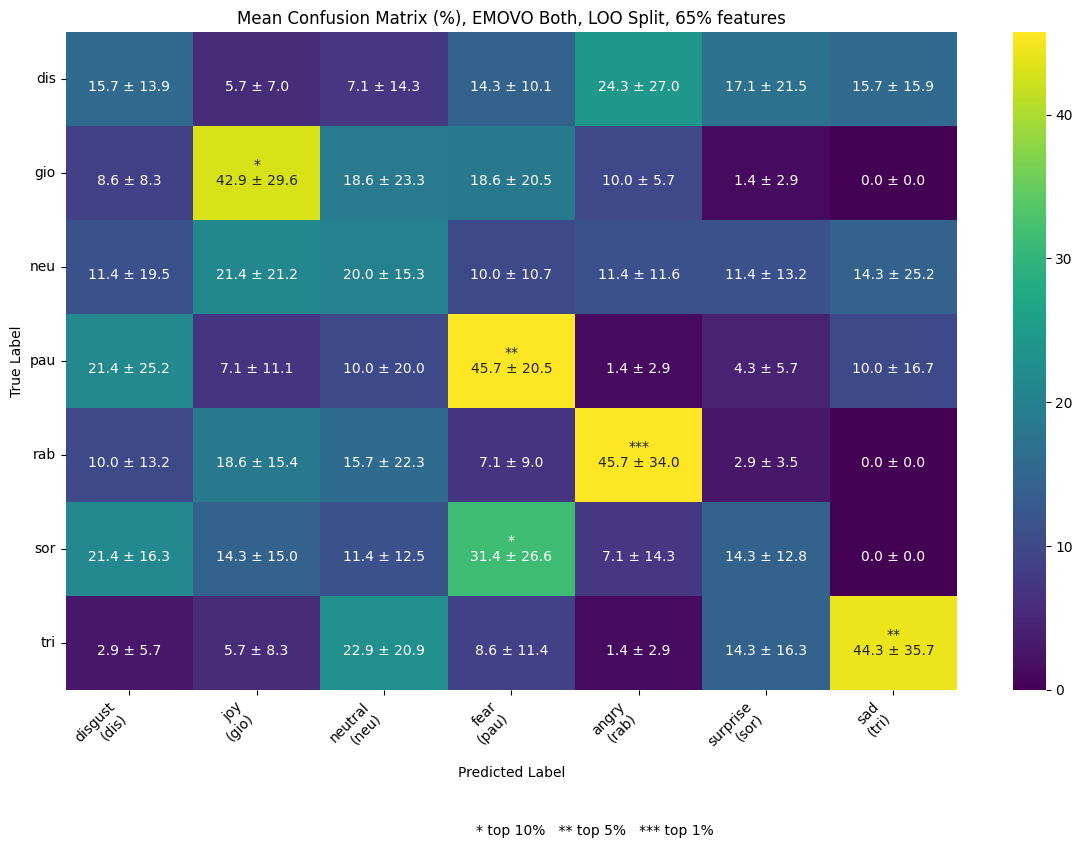

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_emovo_speaker_both.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}"

y_list = ['dis', 'gio', 'neu', 'pau', 'rab', 'sor', 'tri']
x_list = ['disgust\n(dis)', 'joy\n(gio)', 'neutral\n(neu)','fear\n(pau)', 'angry\n(rab)', 'surprise\n(sor)', 'sad\n(tri)']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(x_list)) + 0.5)
ax.set_yticks(np.arange(len(y_list)) + 0.5)
ax.set_xticklabels(x_list, rotation=45, ha="right")
ax.set_yticklabels(y_list, rotation=0)

plt.title("Mean Confusion Matrix (%), EMOVO Both, LOO Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%",
            ha="center", fontsize=10)
plt.show()
